# Fractal Number Efficiency Experiment / Эксперимент эффективности фрактальных чисел

**RU.** Этот notebook отделяет два разных вопроса эффективности фрактальных чисел:

1. **Хранение числа как числа.** Здесь мы сравниваем обычный бинарный ID, хранение через параметры фрактального алфавита и идеализированное хранение через абсолютную амплитуду.
2. **Хранение фрактальной таблицы состояний.** Здесь мы сравниваем компактное генераторное описание с материализованной временной структурой: амплитудным следом `A(t)` и плотной таблицей каналов `C_i(t)`.

Главная идея: если фрактальное число хранится как амплитудная величина и декодер способен надежно различать нужные уровни, то число может занимать один amplitude-slot вместо длинного бинарного слова. Если же амплитуда оцифровывается в обычные биты, информационная цена возвращается к требуемой точности.

**EN.** This notebook separates two different efficiency questions for fractal numbers:

1. **Storing a number as a number.** We compare a standard binary ID, storage through fractal-alphabet generator parameters, and idealized storage through absolute amplitude.
2. **Storing a fractal state table.** We compare the compact generator description against materialized temporal structures: the amplitude trace `A(t)` and the dense channel table `C_i(t)`.

The main idea is that if a fractal number is stored as an amplitude magnitude and the decoder can reliably distinguish the required levels, the number can occupy one amplitude slot instead of a long binary word. If the amplitude is digitized back into ordinary bits, the information cost returns through the required precision.

## Notebook Structure / Структура notebook

1. Metrics and helper functions / метрики и функции.
2. Case A: number storage as generator parameters / хранение числа как параметров генераторов.
3. Case B: number storage as amplitude magnitude / хранение числа как амплитудной величины.
4. Case C: state-table storage efficiency / эффективность хранения таблицы состояний.
5. Practical interpretation and hardware caveats / практическая интерпретация и аппаратные ограничения.

In [1]:
from pathlib import Path
import math
import sys

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "experiments" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from snn_framework import MatrixFractalNumber

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 120)


def bits_for_levels(levels: int) -> int:
    return max(1, math.ceil(math.log2(levels)))


def capacity_bits(model: MatrixFractalNumber, digit_count: int) -> float:
    return sum(math.log2(model.radix(i)) for i in range(digit_count))


def digit_count_for_bits(model: MatrixFractalNumber, target_bits: int) -> int:
    total = 0.0
    digit_count = 0
    while total < target_bits:
        total += math.log2(model.radix(digit_count))
        digit_count += 1
    return digit_count


def max_value_for_bits(bits: int) -> int:
    return (1 << bits) - 1


def required_payload_ticks(cells) -> int:
    return max(cell.shift_ticks + 3 * cell.period_ticks for cell in cells) + 1


def generator_parameter_row(model: MatrixFractalNumber, target_bits: int, alphabet_height: int) -> dict:
    digit_count = digit_count_for_bits(model, target_bits)
    value = max_value_for_bits(target_bits)
    cells = model.encode_cells(value, digit_count=digit_count)
    covered = capacity_bits(model, digit_count)
    minimal_binary_bits = math.ceil(covered)
    period_index_shift_bits = sum(
        bits_for_levels(len(model.channel_alphabet(cell.digit_index).periods)) + bits_for_levels(cell.period_ticks)
        for cell in cells
    )
    absolute_period_shift_bits = sum(
        bits_for_levels(cell.period_ticks + 1) + bits_for_levels(cell.period_ticks)
        for cell in cells
    )
    return {
        "target ID bits": target_bits,
        "alphabet height": alphabet_height,
        "fractal digits": digit_count,
        "covered capacity bits": round(covered, 2),
        "minimal binary bits": minimal_binary_bits,
        "period_index + S bits": period_index_shift_bits,
        "absolute P + S bits": absolute_period_shift_bits,
        "parameter overhead vs binary, %": round((period_index_shift_bits / minimal_binary_bits - 1) * 100, 2),
        "addressing density": round(covered / period_index_shift_bits, 4),
    }


def amplitude_number_row(target_bits: int) -> dict:
    return {
        "target ID bits": target_bits,
        "binary scalar bits": target_bits,
        "amplitude slots": 1,
        "distinguishable amplitude levels": f"2^{target_bits}",
        "required effective precision, bits": target_bits,
        "relative amplitude step": f"2^-{target_bits}",
        "ideal slot gain vs binary": target_bits,
        "digital precision bits if quantized": target_bits,
        "digital bit gain if quantized": 1.0,
    }


def state_table_row(model: MatrixFractalNumber, target_bits: int, alphabet_height: int) -> dict:
    digit_count = digit_count_for_bits(model, target_bits)
    value = max_value_for_bits(target_bits)
    cells = model.encode_cells(value, digit_count=digit_count)
    covered = capacity_bits(model, digit_count)
    parameter_bits = sum(
        bits_for_levels(len(model.channel_alphabet(cell.digit_index).periods)) + bits_for_levels(cell.period_ticks)
        for cell in cells
    )
    latency_ticks = required_payload_ticks(cells)
    amplitude_resolution_bits = bits_for_levels(digit_count + 1)
    unfolded_amplitude_bits = latency_ticks * amplitude_resolution_bits
    dense_channel_table_bits = latency_ticks * digit_count
    return {
        "target payload bits": target_bits,
        "alphabet height": alphabet_height,
        "fractal digits": digit_count,
        "covered capacity bits": round(covered, 2),
        "generator parameter bits": parameter_bits,
        "latency ticks": latency_ticks,
        "amplitude levels in A(t)": digit_count + 1,
        "bits per A(t) sample": amplitude_resolution_bits,
        "stored A(t) bits": unfolded_amplitude_bits,
        "dense C_i(t) table bits": dense_channel_table_bits,
        "gain vs stored A(t)": round(unfolded_amplitude_bits / parameter_bits, 2),
        "gain vs dense C_i(t)": round(dense_channel_table_bits / parameter_bits, 2),
    }

## 1. Case A: Storing Numbers As Generator Parameters / Кейс A: хранение чисел как параметров генераторов

**RU.** Первый вариант — хранить число как выбранные ячейки фрактального алфавита. Для каждого разряда сохраняется `period_index` и `S_i`. Если правило построения алфавита известно заранее, абсолютный период `P_i` можно восстановить и не хранить отдельно.

Этот способ не дает радикального выигрыша относительно минимального бинарного ID. Он нужен для другого: число сразу находится в генераторной форме, пригодной для импульсного разворачивания и передачи.

**EN.** The first option is to store the number as selected cells of the fractal alphabet. For each digit we store `period_index` and `S_i`. If the alphabet construction rule is known, the absolute period `P_i` can be reconstructed and does not need to be stored.

This method does not provide radical savings compared with a minimal binary ID. Its value is that the number is already in generator form, ready for pulse-based unfolding and transmission.

### Addressing Density Formula / Формула плотности адресации

**RU.** Для параметрического хранения числа используем метрику `addressing density`: сколько бит адресного пространства приходится на один сохраненный бит параметров.

$$
Density = \frac{\log_2\left(\prod_i Base_i\right)}{bits(period\_index, S)}
$$

Если `Density ≈ 1`, параметрическая форма близка к бинарному optimum. Если `Density < 1`, мы платим overhead за генераторную структуру. Если `Density > 1`, один сохраненный бит параметров покрывает больше одного бита адресного пространства, но такую ситуацию нужно проверять на корректность битовой модели хранения.

**EN.** For parameter-based number storage we use `addressing density`: the number of address-space bits represented by one stored parameter bit.

$$
Density = \frac{\log_2\left(\prod_i Base_i\right)}{bits(period\_index, S)}
$$

If `Density ≈ 1`, the parameter form is close to the binary optimum. If `Density < 1`, the generator structure has overhead. If `Density > 1`, one stored parameter bit covers more than one address-space bit, but such a result must be checked against the exact bit-storage model.

,target ID bits,alphabet height,fractal digits,covered capacity bits,minimal binary bits,period_index + S bits,absolute P + S bits,"parameter overhead vs binary, %",addressing density
0,128,32,11,132.97,133,139,168,4.51,0.9566
1,256,32,20,258.41,259,267,334,3.09,0.9678
2,512,32,38,525.47,526,545,710,3.61,0.9642
3,1024,32,70,1028.97,1029,1061,1422,3.11,0.9698
4,2048,32,132,2060.38,2061,2121,2922,2.91,0.9714
5,4096,32,249,4113.81,4114,4225,5960,2.70,0.9737
6,8192,32,470,8194.94,8195,8420,12140,2.75,0.9733
7,16384,32,893,16396.41,16397,16835,24740,2.67,0.9739
8,128,64,10,139.43,140,145,170,3.57,0.9616
9,256,64,18,265.75,266,275,334,3.38,0.9664


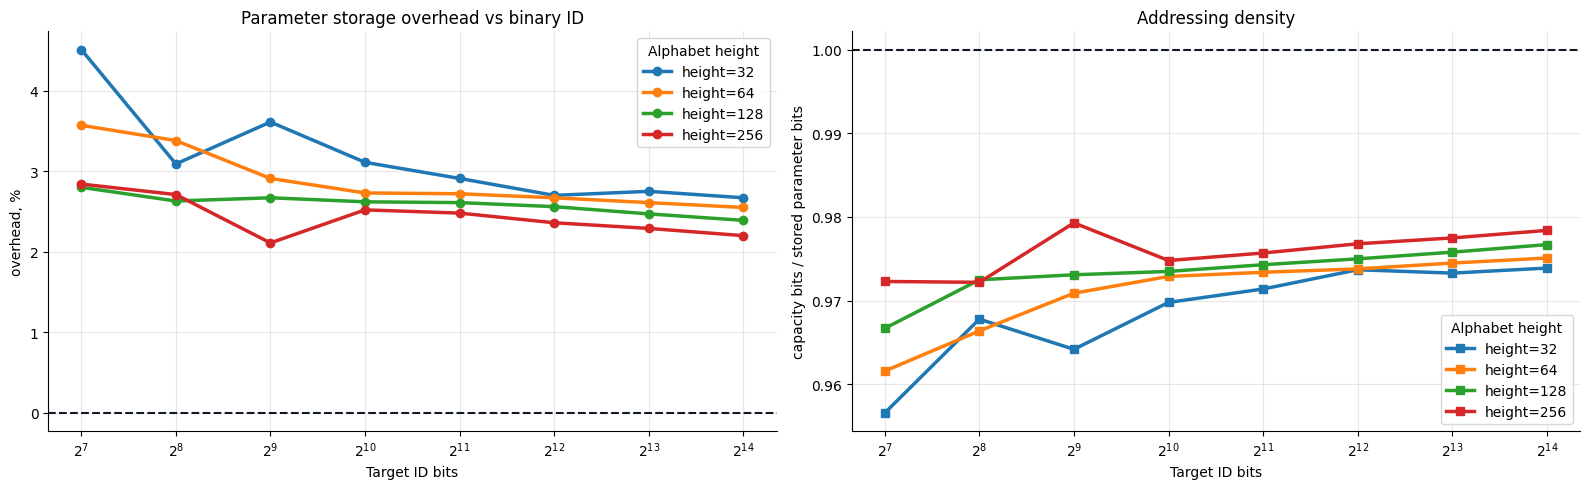

In [2]:
id_bit_grid = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]
parameter_alphabet_heights = [32, 64, 128, 256]

parameter_rows = []
for height in parameter_alphabet_heights:
    model = MatrixFractalNumber.from_contiguous_bands(start=2, width=height)
    for bits in id_bit_grid:
        parameter_rows.append(generator_parameter_row(model, bits, alphabet_height=height))

parameter_df = pd.DataFrame(parameter_rows)
display(parameter_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for height in parameter_alphabet_heights:
    group = parameter_df[parameter_df["alphabet height"] == height]
    axes[0].plot(group["target ID bits"], group["parameter overhead vs binary, %"], marker="o", linewidth=2.5, label=f"height={height}")
    axes[1].plot(group["target ID bits"], group["addressing density"], marker="s", linewidth=2.5, label=f"height={height}")

axes[0].axhline(0, color="#111827", linestyle="--", linewidth=1.5)
axes[0].set_title("Parameter storage overhead vs binary ID")
axes[0].set_ylabel("overhead, %")
axes[1].axhline(1, color="#111827", linestyle="--", linewidth=1.5)
axes[1].set_title("Addressing density")
axes[1].set_ylabel("capacity bits / stored parameter bits")

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Target ID bits")
    ax.legend(title="Alphabet height")
    ax.grid(True, which="both", alpha=0.3)
fig.tight_layout();

### Table Field Definitions / Определения полей таблицы

**RU.**

- `target ID bits`: битность пространства идентификаторов.
- `alphabet height`: количество строк периода в алфавите каждого разряда.
- `fractal digits`: число фрактальных разрядов, нужных для покрытия ID-пространства.
- `covered capacity bits`: фактическая емкость выбранной глубины, `log2(prod(Base_i))`.
- `minimal binary bits`: минимальный бинарный размер для фактически покрытой емкости.
- `period_index + S bits`: размер хранения ячеек как индекса периода и сдвига.
- `absolute P + S bits`: размер хранения абсолютного периода и сдвига.
- `parameter overhead vs binary, %`: overhead параметрического хранения относительно binary ID.
- `addressing density`: сколько бит емкости приходится на один сохраненный бит параметров.

**EN.**

- `target ID bits`: bit width of the identifier space.
- `alphabet height`: number of period rows in each digit alphabet.
- `fractal digits`: number of fractal digits required to cover the ID space.
- `covered capacity bits`: actual capacity of the selected depth, `log2(prod(Base_i))`.
- `minimal binary bits`: minimum binary size for the actually covered capacity.
- `period_index + S bits`: storage size for cells as period index plus shift.
- `absolute P + S bits`: storage size for absolute period plus shift.
- `parameter overhead vs binary, %`: parameter-storage overhead relative to binary ID storage.
- `addressing density`: capacity bits represented by one stored parameter bit.

### Interpretation / Интерпретация

**RU.** Параметры генераторов обычно близки к бинарному оптимуму, но не дают сильного сжатия числа как скаляра. Их смысл в том, что число сразу хранится в форме, из которой можно восстановить фрактальный генератор.

**EN.** Generator parameters are usually close to the binary optimum, but they do not strongly compress a scalar number. Their value is that the number is already stored in a form from which the fractal generator can be reconstructed.

## 2. Case B: Storing Numbers As Amplitude Magnitudes / Кейс B: хранение чисел как амплитудных величин

**RU.** Второй вариант — хранить число как абсолютную величину амплитуды. В идеализированной модели один amplitude-slot может представить значение из диапазона `0..2^B-1`, если физический носитель и декодер различают `2^B` уровней.

Именно здесь появляется сильный выигрыш по количеству хранимых слотов: вместо `B` бинарных ячеек используется одна амплитудная ячейка. Но этот выигрыш не бесплатный: требуется `B` бит эффективной точности (`ENOB`) и относительный шаг различения порядка `2^-B`.

**EN.** The second option is to store the number as an absolute amplitude magnitude. In the idealized model, one amplitude slot can represent a value from `0..2^B-1` if the physical medium and decoder can distinguish `2^B` levels.

This is where a strong slot-count gain appears: one amplitude cell replaces `B` binary cells. But the gain is not free: it requires `B` effective precision bits (`ENOB`) and a relative discrimination step on the order of `2^-B`.

,target ID bits,binary scalar bits,amplitude slots,distinguishable amplitude levels,"required effective precision, bits",relative amplitude step,ideal slot gain vs binary,digital precision bits if quantized,digital bit gain if quantized
0,128,128,1,2^128,128,2^-128,128,128,1.0
1,256,256,1,2^256,256,2^-256,256,256,1.0
2,512,512,1,2^512,512,2^-512,512,512,1.0
3,1024,1024,1,2^1024,1024,2^-1024,1024,1024,1.0
4,2048,2048,1,2^2048,2048,2^-2048,2048,2048,1.0
5,4096,4096,1,2^4096,4096,2^-4096,4096,4096,1.0
6,8192,8192,1,2^8192,8192,2^-8192,8192,8192,1.0
7,16384,16384,1,2^16384,16384,2^-16384,16384,16384,1.0


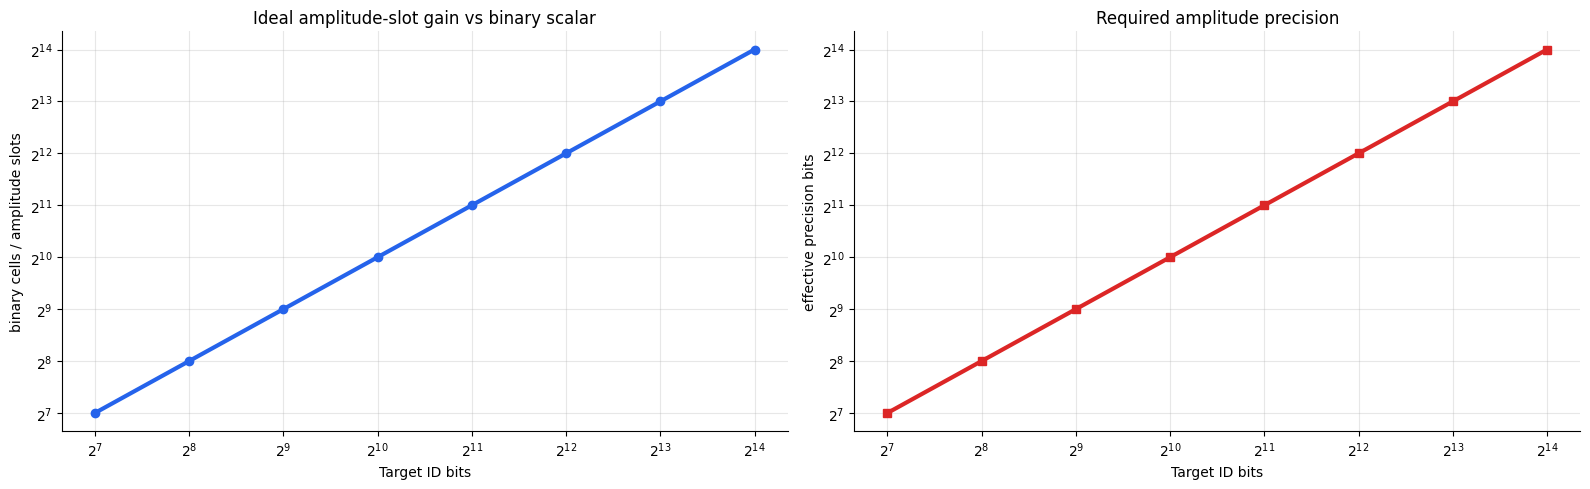

In [3]:
amplitude_df = pd.DataFrame([amplitude_number_row(bits) for bits in id_bit_grid])
display(amplitude_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(amplitude_df["target ID bits"], amplitude_df["ideal slot gain vs binary"], marker="o", linewidth=3, color="#2563EB")
axes[0].set_title("Ideal amplitude-slot gain vs binary scalar")
axes[0].set_ylabel("binary cells / amplitude slots")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log", base=2)

axes[1].plot(amplitude_df["target ID bits"], amplitude_df["required effective precision, bits"], marker="s", linewidth=3, color="#DC2626")
axes[1].set_title("Required amplitude precision")
axes[1].set_ylabel("effective precision bits")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log", base=2)

for ax in axes:
    ax.set_xlabel("Target ID bits")
    ax.grid(True, which="both", alpha=0.3)
fig.tight_layout();

### Table Field Definitions / Определения полей таблицы

**RU.**

- `target ID bits`: битность пространства идентификаторов.
- `binary scalar bits`: сколько бит нужно обычному бинарному числу.
- `amplitude slots`: сколько физических амплитудных ячеек используется в идеализированной модели.
- `distinguishable amplitude levels`: сколько уровней амплитуды должен различать декодер.
- `required effective precision, bits`: требуемая эффективная точность амплитудного хранения.
- `relative amplitude step`: относительный шаг между соседними уровнями.
- `ideal slot gain vs binary`: выигрыш по числу слотов относительно бинарных ячеек.
- `digital precision bits if quantized`: сколько бит снова потребуется, если амплитуду хранить цифровым квантованным способом.
- `digital bit gain if quantized`: выигрыш по битам после цифрового квантования; для точного хранения он равен `1`.

**EN.**

- `target ID bits`: bit width of the identifier space.
- `binary scalar bits`: number of bits required by an ordinary binary number.
- `amplitude slots`: number of physical amplitude cells in the idealized model.
- `distinguishable amplitude levels`: number of amplitude levels the decoder must distinguish.
- `required effective precision, bits`: required effective precision of amplitude storage.
- `relative amplitude step`: relative spacing between neighboring levels.
- `ideal slot gain vs binary`: slot-count gain relative to binary cells.
- `digital precision bits if quantized`: number of bits required again if the amplitude is stored digitally.
- `digital bit gain if quantized`: bit gain after digital quantization; for exact storage it is `1`.

### Interpretation / Интерпретация

**RU.** Если мы считаем физические ячейки, amplitude-storage дает сжатие: `B` бинарных ячеек заменяются одним amplitude-slot. Если же мы считаем цифровые биты точности, сжатие исчезает: чтобы точно различить `2^B` уровней, нужно `B` effective bits. Поэтому amplitude-форма выгодна только при наличии физической памяти и декодера, которые действительно работают с такими уровнями.

**EN.** If we count physical cells, amplitude storage compresses strongly: `B` binary cells are replaced by one amplitude slot. If we count digital precision bits, the compression disappears: exactly distinguishing `2^B` levels requires `B` effective bits. Therefore amplitude form is beneficial only when the physical memory and decoder can actually operate on those levels.

## 3. Combined View: Number Storage / Общий вид: хранение числа

**RU.** Теперь сведем два способа хранения числа в одну таблицу. Для чистого ID есть три разных критерия:

- binary storage оптимален по цифровым битам;
- generator-parameter storage почти бинарно оптимален, но сразу дает структуру фрактального генератора;
- amplitude storage оптимален по числу физических слотов, но требует огромной точности различения уровней.

**EN.** Now we combine both number-storage methods in one table. For a pure ID there are three different criteria:

- binary storage is optimal in digital bits;
- generator-parameter storage is near binary-optimal but immediately provides the fractal generator structure;
- amplitude storage is optimal in physical slot count but requires extremely high level-discrimination precision.

,target ID bits,binary scalar bits,generator parameter bits,"parameter overhead vs binary, %",amplitude slots,ideal amplitude slot gain,required amplitude levels,required amplitude precision bits
0,128,128,145,3.57,1,128,2^128,128
1,256,256,275,3.38,1,256,2^256,256
2,512,512,531,2.91,1,512,2^512,512
3,1024,1024,1053,2.73,1,1024,2^1024,1024
4,2048,2048,2115,2.72,1,2048,2^2048,2048
5,4096,4096,4225,2.67,1,4096,2^4096,4096
6,8192,8192,8413,2.61,1,8192,2^8192,8192
7,16384,16384,16819,2.55,1,16384,2^16384,16384


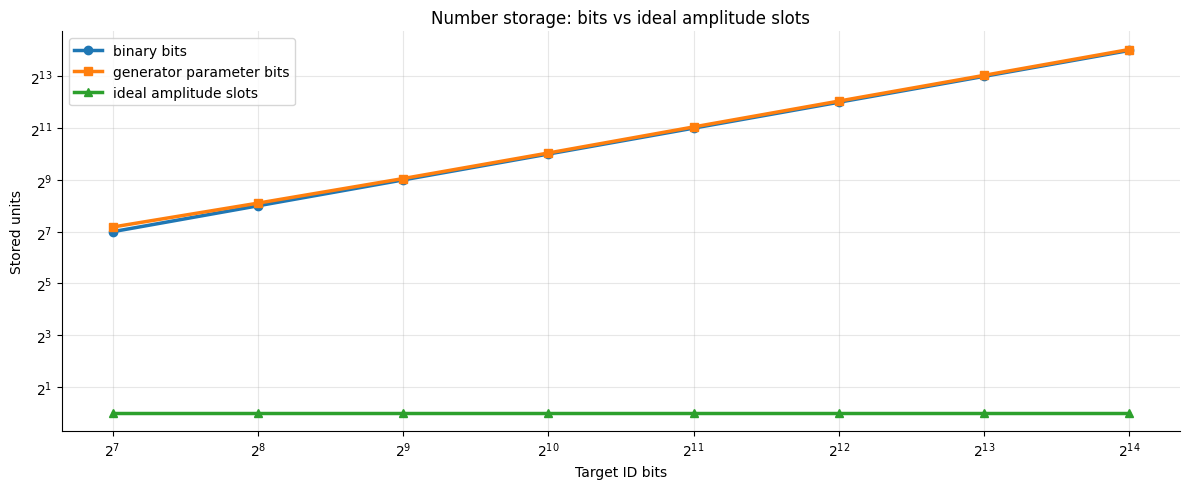

In [4]:
comparison_height = 64
comparison_model = MatrixFractalNumber.from_contiguous_bands(start=2, width=comparison_height)
comparison_rows = []
for bits in id_bit_grid:
    parameter = generator_parameter_row(comparison_model, bits, alphabet_height=comparison_height)
    amplitude = amplitude_number_row(bits)
    comparison_rows.append({
        "target ID bits": bits,
        "binary scalar bits": bits,
        "generator parameter bits": parameter["period_index + S bits"],
        "parameter overhead vs binary, %": parameter["parameter overhead vs binary, %"],
        "amplitude slots": amplitude["amplitude slots"],
        "ideal amplitude slot gain": amplitude["ideal slot gain vs binary"],
        "required amplitude levels": amplitude["distinguishable amplitude levels"],
        "required amplitude precision bits": amplitude["required effective precision, bits"],
    })

number_comparison_df = pd.DataFrame(comparison_rows)
display(number_comparison_df)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(number_comparison_df["target ID bits"], number_comparison_df["binary scalar bits"], marker="o", linewidth=2.5, label="binary bits")
ax.plot(number_comparison_df["target ID bits"], number_comparison_df["generator parameter bits"], marker="s", linewidth=2.5, label="generator parameter bits")
ax.plot(number_comparison_df["target ID bits"], number_comparison_df["amplitude slots"], marker="^", linewidth=2.5, label="ideal amplitude slots")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("Target ID bits")
ax.set_ylabel("Stored units")
ax.set_title("Number storage: bits vs ideal amplitude slots")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout();

### Table Field Definitions / Определения полей таблицы

**RU.**

- `target ID bits`: битность пространства идентификаторов.
- `binary scalar bits`: размер обычного бинарного хранения ID.
- `generator parameter bits`: размер хранения через параметры фрактальных разрядов.
- `parameter overhead vs binary, %`: overhead параметров относительно binary ID.
- `amplitude slots`: число амплитудных ячеек в идеализированной аналоговой модели.
- `ideal amplitude slot gain`: выигрыш по числу физических слотов относительно бинарных ячеек.
- `required amplitude levels`: число уровней, которые должна различать память/декодер.
- `required amplitude precision bits`: требуемая эффективная точность амплитуды.

**EN.**

- `target ID bits`: bit width of the identifier space.
- `binary scalar bits`: ordinary binary ID storage size.
- `generator parameter bits`: storage size through fractal digit parameters.
- `parameter overhead vs binary, %`: parameter overhead relative to binary ID storage.
- `amplitude slots`: number of amplitude cells in the idealized analog model.
- `ideal amplitude slot gain`: physical slot-count gain relative to binary cells.
- `required amplitude levels`: number of levels the memory/decoder must distinguish.
- `required amplitude precision bits`: required effective amplitude precision.

## 4. Case C: Storing The Fractal State Table / Кейс C: хранение фрактальной таблицы состояний

**RU.** Теперь рассматриваем другой объект: не число как scalar ID, а развернутую временную структуру фрактального числа. Здесь фрактальный генератор задает таблицу каналов `C_i(t)` и суммарный амплитудный поток `A(t)`.

Если хранить эту структуру явно, объем данных растет как произведение времени наблюдения и числа каналов. Если хранить только параметры генераторов, та же структура восстанавливается процедурно.

**EN.** Now we consider a different object: not the number as a scalar ID, but the unfolded temporal structure of a fractal number. The fractal generator defines the channel table `C_i(t)` and the summed amplitude stream `A(t)`.

If this structure is stored explicitly, data size grows with observation time and channel count. If only generator parameters are stored, the same structure is reconstructed procedurally.

,target payload bits,alphabet height,fractal digits,covered capacity bits,generator parameter bits,latency ticks,amplitude levels in A(t),bits per A(t) sample,stored A(t) bits,dense C_i(t) table bits,gain vs stored A(t),gain vs dense C_i(t)
0,128,16,13,134.43,141,630,14,4,2520,8190,17.87,58.09
1,256,16,23,256.02,267,1401,24,5,7005,32223,26.24,120.69
2,512,16,43,516.54,540,2603,44,6,15618,111929,28.92,207.28
3,1024,16,80,1031.67,1072,4436,81,7,31052,354880,28.97,331.04
4,2048,16,149,2054.11,2129,9006,150,8,72048,1341894,33.84,630.29
5,4096,16,279,4097.62,4232,17188,280,9,154692,4795452,36.55,1133.14
6,128,32,11,132.97,139,1067,12,4,4268,11737,30.71,84.44
7,256,32,20,258.41,267,2052,21,5,10260,41040,38.43,153.71
8,512,32,38,525.47,545,4257,39,6,25542,161766,46.87,296.82
9,1024,32,70,1028.97,1061,7756,71,7,54292,542920,51.17,511.71


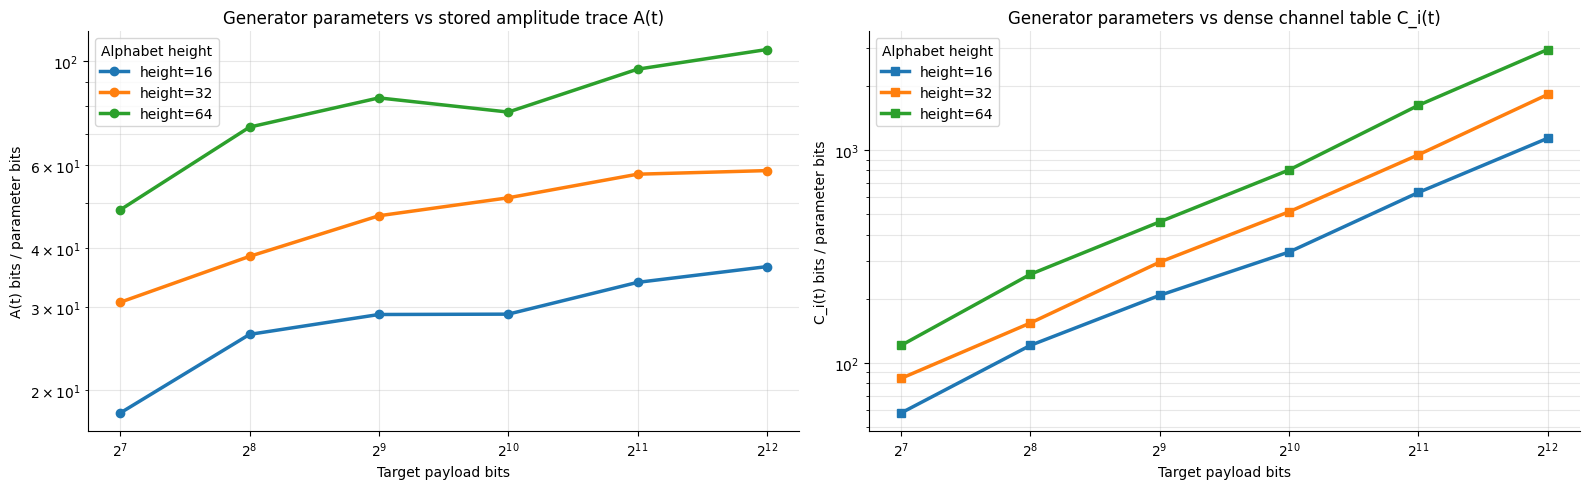

In [5]:
state_payload_grid = [128, 256, 512, 1024, 2048, 4096]
state_alphabet_heights = [16, 32, 64]

state_rows = []
for height in state_alphabet_heights:
    model = MatrixFractalNumber.from_contiguous_bands(start=2, width=height)
    for bits in state_payload_grid:
        state_rows.append(state_table_row(model, bits, alphabet_height=height))

state_df = pd.DataFrame(state_rows)
display(state_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for height in state_alphabet_heights:
    group = state_df[state_df["alphabet height"] == height]
    axes[0].plot(group["target payload bits"], group["gain vs stored A(t)"], marker="o", linewidth=2.5, label=f"height={height}")
    axes[1].plot(group["target payload bits"], group["gain vs dense C_i(t)"], marker="s", linewidth=2.5, label=f"height={height}")

axes[0].set_title("Generator parameters vs stored amplitude trace A(t)")
axes[0].set_ylabel("A(t) bits / parameter bits")
axes[1].set_title("Generator parameters vs dense channel table C_i(t)")
axes[1].set_ylabel("C_i(t) bits / parameter bits")

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log", base=10)
    ax.set_xlabel("Target payload bits")
    ax.legend(title="Alphabet height")
    ax.grid(True, which="both", alpha=0.3)
fig.tight_layout();

### Table Field Definitions / Определения полей таблицы

**RU.**

- `target payload bits`: целевой размер полезной информации.
- `alphabet height`: высота фрактального алфавита.
- `fractal digits`: число разрядов-генераторов.
- `covered capacity bits`: фактическая емкость выбранной глубины.
- `generator parameter bits`: сколько бит нужно для хранения параметров генераторов.
- `latency ticks`: окно наблюдения, нужное для гарантированного разворачивания/декодирования текущей модели.
- `amplitude levels in A(t)`: число возможных уровней суммарной амплитуды.
- `bits per A(t) sample`: сколько бит нужно для хранения одного дискретного отсчета `A(t)`.
- `stored A(t) bits`: объем хранения полного амплитудного следа.
- `dense C_i(t) table bits`: объем хранения полной таблицы состояний всех каналов.
- `gain vs stored A(t)`: выигрыш параметрического хранения относительно полного `A(t)`.
- `gain vs dense C_i(t)`: выигрыш параметрического хранения относительно полной таблицы `C_i(t)`.

**EN.**

- `target payload bits`: target useful information size.
- `alphabet height`: fractal alphabet height.
- `fractal digits`: number of digit-generators.
- `covered capacity bits`: actual capacity of the selected depth.
- `generator parameter bits`: number of bits required to store generator parameters.
- `latency ticks`: observation window required by the current unfolding/decoding model.
- `amplitude levels in A(t)`: number of possible summed-amplitude levels.
- `bits per A(t) sample`: bits required to store one discrete `A(t)` sample.
- `stored A(t) bits`: storage size of the full amplitude trace.
- `dense C_i(t) table bits`: storage size of the full channel-state table.
- `gain vs stored A(t)`: parameter-storage gain relative to full `A(t)` storage.
- `gain vs dense C_i(t)`: parameter-storage gain relative to full `C_i(t)` table storage.

### Interpretation / Интерпретация

**RU.** В этом кейсе выигрыш уже измеряется не относительно скалярного ID, а относительно материализованной временной структуры. Поэтому он может быть десятки, сотни и тысячи раз: генераторные параметры заменяют явное хранение каждого такта и каждого канала.

**EN.** In this case the gain is measured not against a scalar ID, but against the materialized temporal structure. Therefore it can reach tens, hundreds, or thousands of times: generator parameters replace explicit storage of every tick and every channel.

## 5. Conclusions And Hardware Interpretation / Выводы и аппаратная интерпретация

**RU.** В этом notebook получаются два разных вывода.

**1. Если мы храним число как число:**

- бинарный integer остается сильным цифровым baseline;
- хранение через параметры генераторов близко к бинарному optimum и дает готовую фрактальную структуру;
- хранение через абсолютную амплитуду дает сильное сжатие по числу физических слотов: один amplitude-slot вместо `B` binary cells;
- цена amplitude-подхода — необходимость надежно различать `2^B` уровней и иметь `B` бит эффективной точности.

**2. Если мы храним фрактальную таблицу состояний:**

- хранение полного `A(t)` или полной таблицы `C_i(t)` резко увеличивает объем данных;
- хранение параметров генераторов дает большой выигрыш, потому что временная структура восстанавливается процедурно.

Практический вывод: для хранения и передачи фрактальных чисел наиболее компактной формой является амплитудная форма, если вычислитель и память реально поддерживают требуемые уровни амплитуды. При этом фрактальный алфавит остается важным, потому что он раскладывает число на структурированные period-shift параметры и не требует одного недифференцированного сверхточного значения во всех сценариях.

Выигрыш у amplitude будет только если есть физический носитель, который реально и надежно различает сверхмного амплитудных уровней. Для SNN/нейроморфного железа это может быть сложной ставкой: шум, дрейф, квантование, энергозатраты АЦП/ЦАП. Фрактальный алфавит как раз интересен тем, что не требует одного чудовищно точного амплитудного значения, а раскладывает число на структурированные period-shift параметры.

**EN.** This notebook gives two different conclusions.

**1. If we store a number as a number:**

- binary integer remains a strong digital baseline;
- generator-parameter storage stays close to the binary optimum and gives a ready fractal structure;
- absolute-amplitude storage gives strong compression in physical slot count: one amplitude slot instead of `B` binary cells;
- the cost of amplitude storage is the need to reliably distinguish `2^B` levels and maintain `B` effective precision bits.

**2. If we store a fractal state table:**

- storing full `A(t)` or the dense `C_i(t)` table greatly increases data size;
- storing generator parameters gives a large gain because the temporal structure is reconstructed procedurally.

The practical conclusion is that the most compact storage and transmission form for fractal numbers is amplitude form, provided that the computing substrate and memory can really support the required amplitude levels. At the same time, the fractal alphabet remains important because it decomposes the number into structured period-shift parameters and does not require a single undifferentiated ultra-precise value in every scenario.

Amplitude gain exists only if the physical medium can really and reliably distinguish a very large number of amplitude levels. For SNN/neuromorphic hardware this can be a difficult bet: noise, drift, quantization, and ADC/DAC energy costs matter. The fractal alphabet is interesting exactly because it does not require one monstrous high-precision amplitude value; it decomposes the number into structured period-shift parameters.